# Spectral Clustering for Multi-Building Energy Benchmarking

This notebook implements **Spectral Clustering** as part of the clustering-based energy benchmarking framework.

**Pipeline:**
1. load data
2. Explore and prepare PCA-reduced features
3. Select optimal number of clusters (Eigengap heuristic)
4. Run Spectral Clustering
5. Evaluate clusters (Silhouette, Davies-Bouldin, Calinski-Harabasz)
6. Benchmarking analysis (CV reduction, peer-group quality)
7. Visualizations

## 1. Setup & Imports

In [1]:
# Install any missing packages
!pip install -q scikit-learn pandas numpy matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import SpectralClustering
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from scipy.sparse.linalg import eigsh
from scipy.sparse import csr_matrix

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("All imports successful!")

All imports successful!


## 2. Mount Google Drive & Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [3]:
# PATHS to uploade the files
BASE_PATH = '/content/sample_data/data/'

pca_path              = BASE_PATH + 'pca_data.csv'
processed_path        = BASE_PATH + 'processed_data.csv'
clean_path            = BASE_PATH + 'clean_data.csv'
global_baseline_path  = BASE_PATH + 'global_baseline.csv'
facility_baseline_path= BASE_PATH + 'facility_baseline.csv'

# Load
pca_df        = pd.read_csv(pca_path)
processed_df  = pd.read_csv(processed_path)
clean_df      = pd.read_csv(clean_path)
global_base   = pd.read_csv(global_baseline_path, index_col=0)
facility_base = pd.read_csv(facility_baseline_path)

print(f"PCA data:       {pca_df.shape}")
print(f"Processed data: {processed_df.shape}")
print(f"Clean data:     {clean_df.shape}")
print(f"Global baseline:{global_base.shape}")
print(f"Facility base:  {facility_base.shape}")

PCA data:       (135735, 9)
Processed data: (135735, 69)
Clean data:     (135735, 12)
Global baseline:(5, 2)
Facility base:  (58, 12)


## 3. Data Exploration

In [4]:
print("=== PCA Features (9 components) ===")
pca_df.describe().round(3)

=== PCA Features (9 components) ===


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
count,135735.000,135735.000,135735.000,135735.000,135735.000,135735.000,135735.000,135735.000,135735.000
mean,0.000,-0.000,0.000,0.000,0.000,-0.000,-0.000,0.000,0.000
std,1.978,1.216,1.109,0.967,0.937,0.750,0.563,0.322,0.268
min,-3.426,-19.237,-11.546,-10.457,-10.852,-5.412,-6.497,-5.965,-3.222
25%,-1.009,-0.743,-0.532,-0.628,-0.464,-0.501,-0.446,-0.123,-0.103
50%,-0.285,0.104,0.198,-0.061,-0.015,-0.017,0.160,-0.018,0.005
75%,0.569,0.828,0.758,0.575,0.329,0.489,0.365,0.103,0.080
max,44.783,12.721,7.975,4.693,22.225,9.589,10.622,17.139,3.250


In [5]:
print("=== Clean Data Sample ===")
clean_df.head()

=== Clean Data Sample ===


,year,climate,building_class,facility_type,floor_area,year_built,energy_star_rating,electric_eui,fuel_eui,site_eui,source_eui,ghg_emissions_int
0,2011,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,44.811116,24.502495,69.313611,170.109899,5.564099
1,2013,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,73.0,42.412344,44.934004,87.298780,187.019379,6.826763
2,2014,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,47.317704,62.319646,109.578001,216.307017,7.791479
3,2015,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,71.0,46.834912,83.838720,130.685866,236.993372,8.804045
4,2016,4A Mixed - Humid (Baltimore-MD),Commercial,Office - Uncategorized,1390556,1970.0,77.0,44.607659,79.371272,124.005398,224.295466,8.199263


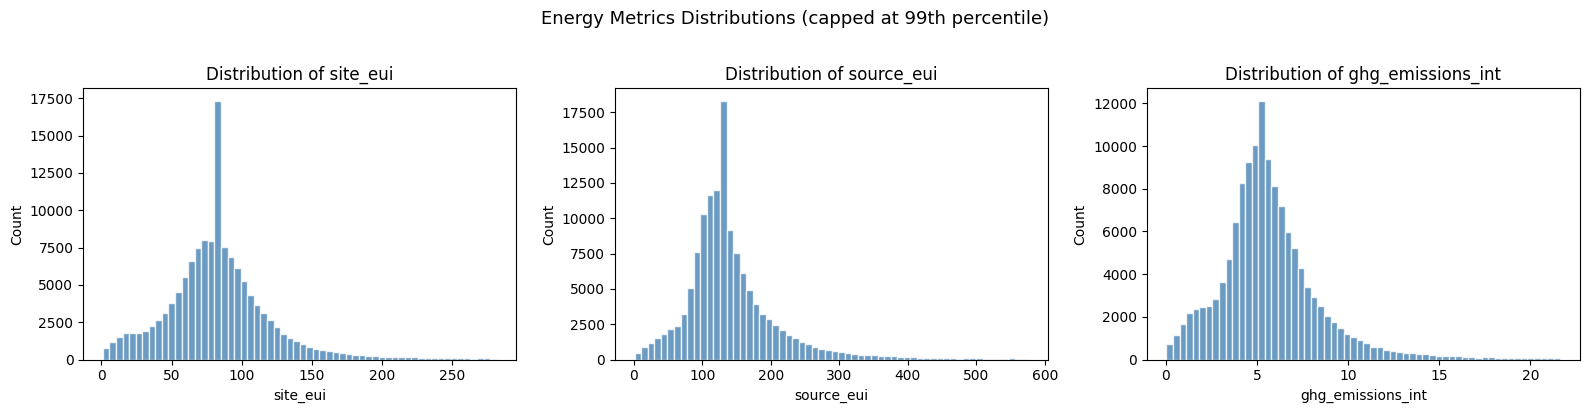

In [6]:
# Distribution of key energy metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
target_cols = ['site_eui', 'source_eui', 'ghg_emissions_int']

for ax, col in zip(axes, target_cols):
    data = clean_df[col].dropna()
    # Clip at 99th percentile for readability
    cap = data.quantile(0.99)
    ax.hist(data[data <= cap], bins=60, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(f'Distribution of {col}', fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Energy Metrics Distributions (capped at 99th percentile)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

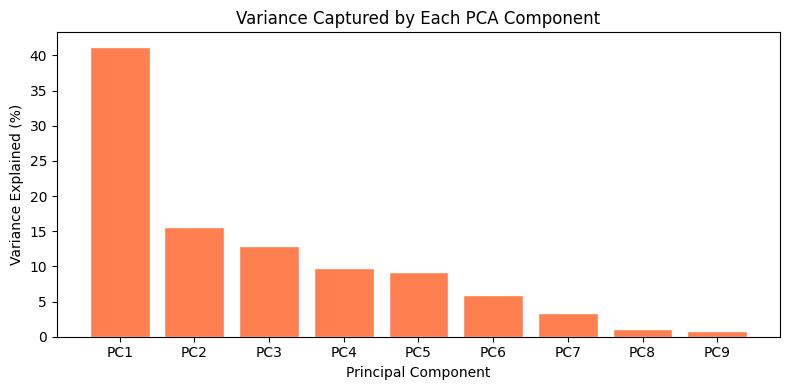

In [7]:
# Variance explained per PCA component
pca_variance = pca_df.var() / pca_df.var().sum() * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(pca_df.columns, pca_variance, color='coral', edgecolor='white')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Variance Explained (%)')
ax.set_title('Variance Captured by Each PCA Component')
plt.tight_layout()
plt.show()

## 4. Prepare Features for Spectral Clustering

Spectral clustering is computationally expensive on large datasets (O(n²) or O(n³)).  
We use a **stratified sample** of 5,000 buildings for clustering, then assign all buildings to clusters using a nearest-centroid approach.

In [8]:
#Feature matrix: use all 9 PCA components
X_full = pca_df.values
print(f"Full feature matrix shape: {X_full.shape}")

# Stratified sample for spectral clustering (memory-efficient)
SAMPLE_SIZE = 5000
sample_idx = np.random.choice(len(X_full), size=SAMPLE_SIZE, replace=False)
X_sample = X_full[sample_idx]

print(f"Sample shape for clustering: {X_sample.shape}")

Full feature matrix shape: (135735, 9)
Sample shape for clustering: (5000, 9)


## 5. Eigengap Heuristic — Choose Optimal k

The eigengap heuristic finds the number of clusters `k` where the gap between consecutive eigenvalues of the graph Laplacian is largest.

In [9]:
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.linalg import eigsh
from scipy.sparse import eye as speye

def compute_eigengap(X, n_neighbors=10, n_components=12):
    """
    Builds a kNN affinity graph and computes the first n_components
    eigenvalues of the normalized graph Laplacian.
    Returns eigenvalues and suggested k.
    """
    # Build symmetric kNN graph
    A = kneighbors_graph(X, n_neighbors=n_neighbors, mode='connectivity',
                         include_self=False)
    A = (A + A.T) / 2   # symmetrize

    # Degree matrix
    degree = np.array(A.sum(axis=1)).flatten()
    D_inv_sqrt = csr_matrix(np.diag(1.0 / np.sqrt(np.where(degree == 0, 1, degree))))

    # Normalized Laplacian: L_sym = I - D^{-1/2} A D^{-1/2}
    L_sym = speye(A.shape[0], format='csr') - D_inv_sqrt @ A @ D_inv_sqrt

    # Smallest eigenvalues (which='SM')
    eigenvalues, _ = eigsh(L_sym, k=n_components, which='SM')
    eigenvalues = np.sort(np.real(eigenvalues))

    # Eigengap
    gaps = np.diff(eigenvalues)
    suggested_k = np.argmax(gaps) + 1   # +1 because argmax gives 0-indexed gap

    return eigenvalues, gaps, suggested_k


print("Computing eigengap on sample data...")
eigenvalues, gaps, suggested_k = compute_eigengap(X_sample, n_neighbors=10, n_components=12)
print(f"\nEigenvalues: {eigenvalues.round(4)}")
print(f"Gaps:        {gaps.round(4)}")
print(f"\n>>> Suggested number of clusters (Eigengap): k = {suggested_k}")

Computing eigengap on sample data...

Eigenvalues: [-0.      0.0061  0.0082  0.0143  0.016   0.0217  0.0248  0.0275  0.0296
  0.0308  0.0372  0.0379]
Gaps:        [0.0061 0.0021 0.006  0.0017 0.0057 0.0031 0.0027 0.0021 0.0012 0.0064
 0.0007]

>>> Suggested number of clusters (Eigengap): k = 10


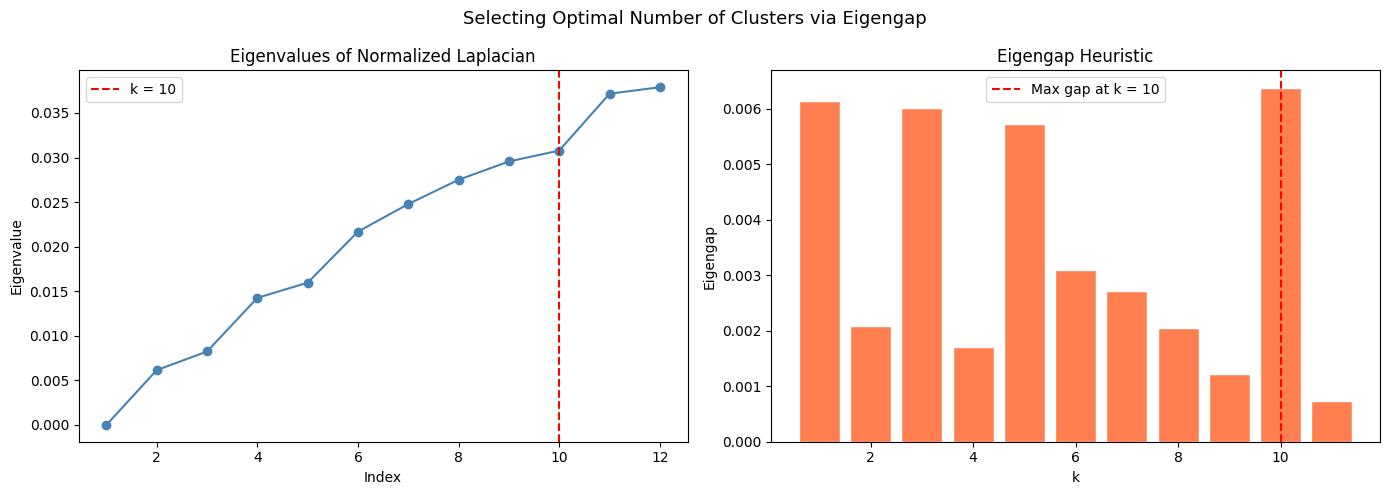

In [10]:
# Plot eigengap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Eigenvalues
axes[0].plot(range(1, len(eigenvalues)+1), eigenvalues, 'o-', color='steelblue')
axes[0].axvline(x=suggested_k, color='red', linestyle='--', label=f'k = {suggested_k}')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Eigenvalue')
axes[0].set_title('Eigenvalues of Normalized Laplacian')
axes[0].legend()

# Gaps
axes[1].bar(range(1, len(gaps)+1), gaps, color='coral', edgecolor='white')
axes[1].axvline(x=suggested_k, color='red', linestyle='--', label=f'Max gap at k = {suggested_k}')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Eigengap')
axes[1].set_title('Eigengap Heuristic')
axes[1].legend()

plt.suptitle('Selecting Optimal Number of Clusters via Eigengap', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Run Spectral Clustering

In [11]:
# k=10
N_CLUSTERS = suggested_k

print(f"Running Spectral Clustering with k = {N_CLUSTERS} ...")
print("(This may take a few minutes on the sample data)")

spectral = SpectralClustering(
    n_clusters=N_CLUSTERS,
    affinity='nearest_neighbors',   # kNN graph (memory-efficient)
    n_neighbors=10,
    assign_labels='kmeans',          # standard label assignment
    random_state=RANDOM_STATE,
    n_jobs=-1
)

sample_labels = spectral.fit_predict(X_sample)

print(f"\nClustering done!")
unique, counts = np.unique(sample_labels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} buildings ({c/SAMPLE_SIZE*100:.1f}%)")

Running Spectral Clustering with k = 10 ...
(This may take a few minutes on the sample data)

Clustering done!
  Cluster 0: 511 buildings (10.2%)
  Cluster 1: 905 buildings (18.1%)
  Cluster 2: 556 buildings (11.1%)
  Cluster 3: 753 buildings (15.1%)
  Cluster 4: 355 buildings (7.1%)
  Cluster 5: 794 buildings (15.9%)
  Cluster 6: 81 buildings (1.6%)
  Cluster 7: 410 buildings (8.2%)
  Cluster 8: 28 buildings (0.6%)
  Cluster 9: 607 buildings (12.1%)


### 6.1 Assign All Buildings to Clusters (Nearest Centroid)

Spectral Clustering cannot directly predict new points. We compute cluster centroids from the sample and assign all 135,735 buildings to the nearest centroid.

In [12]:
from sklearn.metrics.pairwise import euclidean_distances

# Compute centroids from sample
centroids = np.array([
    X_sample[sample_labels == k].mean(axis=0)
    for k in range(N_CLUSTERS)
])
print(f"Centroids shape: {centroids.shape}")

# Assign all buildings to nearest centroid
print("Assigning all buildings to nearest cluster centroid...")
distances = euclidean_distances(X_full, centroids)
all_labels = np.argmin(distances, axis=1)

print(f"All labels assigned. Shape: {all_labels.shape}")
unique_full, counts_full = np.unique(all_labels, return_counts=True)
for u, c in zip(unique_full, counts_full):
    print(f"  Cluster {u}: {c} buildings ({c/len(all_labels)*100:.1f}%)")

Centroids shape: (10, 9)
Assigning all buildings to nearest cluster centroid...
All labels assigned. Shape: (135735,)
  Cluster 0: 16936 buildings (12.5%)
  Cluster 1: 24545 buildings (18.1%)
  Cluster 2: 13558 buildings (10.0%)
  Cluster 3: 14638 buildings (10.8%)
  Cluster 4: 10651 buildings (7.8%)
  Cluster 5: 23548 buildings (17.3%)
  Cluster 6: 6154 buildings (4.5%)
  Cluster 7: 8338 buildings (6.1%)
  Cluster 8: 1338 buildings (1.0%)
  Cluster 9: 16029 buildings (11.8%)


## 7. Evaluation Metrics

In [13]:
# Evaluate on the sample (full dataset is too large for silhouette)
print("Computing clustering evaluation metrics on sample...")

silhouette = silhouette_score(X_sample, sample_labels, random_state=RANDOM_STATE)
davies_bouldin = davies_bouldin_score(X_sample, sample_labels)
calinski_harabasz = calinski_harabasz_score(X_sample, sample_labels)

print(f"\n{'Metric':<30} {'Score':>12}")
print("-" * 45)
print(f"{'Silhouette Score':<30} {silhouette:>12.4f}   (higher is better, max 1.0)")
print(f"{'Davies-Bouldin Index':<30} {davies_bouldin:>12.4f}   (lower is better)")
print(f"{'Calinski-Harabasz Index':<30} {calinski_harabasz:>12.1f}   (higher is better)")

Computing clustering evaluation metrics on sample...

Metric                                Score
---------------------------------------------
Silhouette Score                     0.1269   (higher is better, max 1.0)
Davies-Bouldin Index                 1.4802   (lower is better)
Calinski-Harabasz Index               529.8   (higher is better)


## 8. Benchmarking Analysis

We measure whether clustering improves benchmarking quality by comparing the **Coefficient of Variation (CV)** within clusters versus the global baseline.  
Lower CV within clusters = more homogeneous peer groups = better benchmarking.

In [15]:
# Attach cluster labels to the clean dataframe
clean_df_labeled = clean_df.copy()
clean_df_labeled['cluster'] = all_labels

TARGET_COLS = ['site_eui', 'source_eui', 'ghg_emissions_int']

# Per-cluster statistics
cluster_stats = clean_df_labeled.groupby('cluster')[TARGET_COLS].agg(['mean', 'std'])
cluster_stats.columns = ['_'.join(col) for col in cluster_stats.columns]

# CV per cluster per metric
for col in TARGET_COLS:
    cluster_stats[f'{col}_cv'] = cluster_stats[f'{col}_std'] / cluster_stats[f'{col}_mean']

print("Per-cluster Statistics:")
display(cluster_stats.round(3))

Per-cluster Statistics:


,site_eui_mean,site_eui_std,source_eui_mean,source_eui_std,ghg_emissions_int_mean,ghg_emissions_int_std,site_eui_cv,source_eui_cv,ghg_emissions_int_cv
cluster,,,,,,,,,
0,64.378,22.365,122.661,41.436,4.536,1.642,0.347,0.338,0.362
1,115.068,24.775,166.089,36.587,7.574,1.996,0.215,0.220,0.264
2,76.776,21.239,174.782,50.257,6.020,1.769,0.277,0.288,0.294
3,53.474,25.163,108.313,50.890,3.887,1.924,0.471,0.470,0.495
4,83.100,25.847,133.929,42.862,5.723,2.066,0.311,0.320,0.361
5,75.940,14.033,110.487,21.329,4.847,1.241,0.185,0.193,0.256
6,25.402,15.668,57.044,27.921,1.901,0.944,0.617,0.489,0.496
7,205.849,111.081,426.762,233.315,15.703,8.331,0.540,0.547,0.531
8,110.010,60.665,214.973,97.416,8.001,3.981,0.551,0.453,0.498


In [16]:
# Global stats (baseline)
global_stats = {}
for col in TARGET_COLS:
    g_mean = clean_df[col].mean()
    g_std  = clean_df[col].std()
    global_stats[col] = {'mean': g_mean, 'std': g_std, 'cv': g_std / g_mean}

global_stats_df = pd.DataFrame(global_stats).T
print("Global Baseline Stats:")
display(global_stats_df.round(3))

Global Baseline Stats:


,mean,std,cv
site_eui,86.442,51.196,0.592
source_eui,149.275,103.363,0.692
ghg_emissions_int,5.973,3.900,0.653


In [17]:
# Benchmarking Quality Table 2 , 3
print("\n=== TABLE II: BENCHMARKING QUALITY ===")

bq_rows = []
for col in TARGET_COLS:
    avg_cv = cluster_stats[f'{col}_cv'].mean()
    best_cv = cluster_stats[f'{col}_cv'].min()
    global_cv = global_stats[col]['cv']
    improvement = (global_cv - avg_cv) / global_cv * 100

    bq_rows.append({
        'Metric': col,
        'Global CV': round(global_cv, 3),
        'Avg Cluster CV': round(avg_cv, 3),
        'Best Cluster CV': round(best_cv, 3),
        'Improvement (%)': round(improvement, 1)
    })

bq_df = pd.DataFrame(bq_rows)
display(bq_df)

# Summary for Table III
print("\n=== TABLE III: BENCHMARKING IMPROVEMENT ===")

bi_rows = []
for col in TARGET_COLS:
    global_std = clean_df[col].std()
    cluster_avg_std = cluster_stats[f'{col}_std'].mean()
    improvement = (global_std - cluster_avg_std) / global_std * 100

    bi_rows.append({
        'Method': 'Spectral',
        'Metric': col,
        'Global Std': round(global_std, 3),
        'Cluster Avg Std': round(cluster_avg_std, 3),
        'Improvement (%)': round(improvement, 1)
    })

bi_df = pd.DataFrame(bi_rows)
display(bi_df)


=== TABLE II: BENCHMARKING QUALITY ===


,Metric,Global CV,Avg Cluster CV,Best Cluster CV,Improvement (%)
0,site_eui,0.592,0.372,0.185,37.2
1,source_eui,0.692,0.353,0.193,49.0
2,ghg_emissions_int,0.653,0.385,0.256,41.1



=== TABLE III: BENCHMARKING IMPROVEMENT ===


,Method,Metric,Global Std,Cluster Avg Std,Improvement (%)
0,Spectral,site_eui,51.196,33.768,34.0
1,Spectral,source_eui,103.363,62.771,39.3
2,Spectral,ghg_emissions_int,3.900,2.538,34.9


## 9. Visualizations

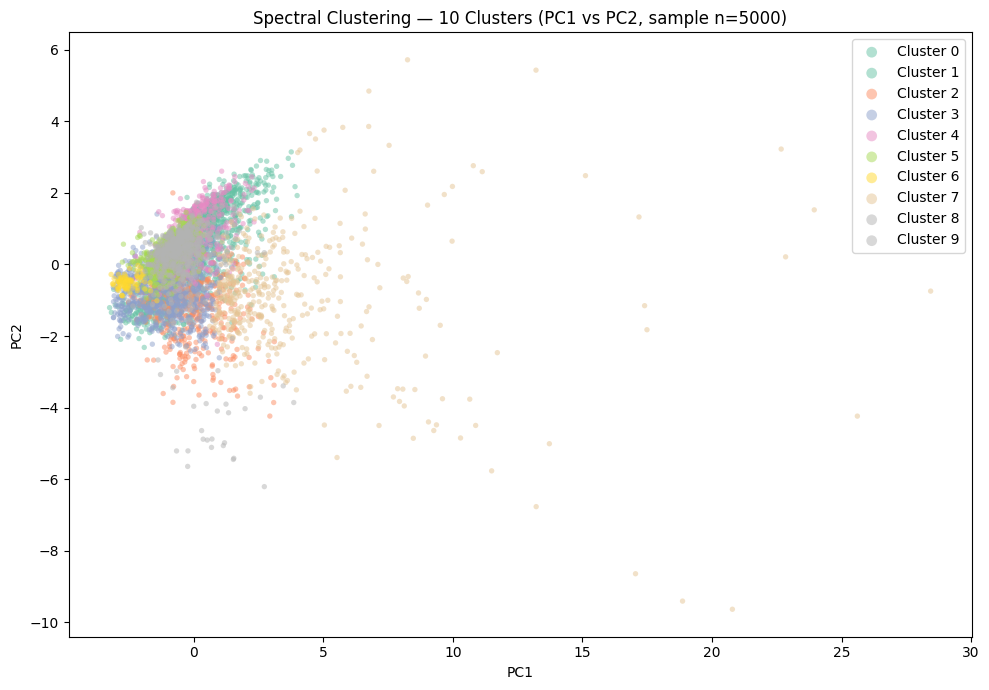

In [18]:
# 9.1 — Cluster distribution in 2D PCA space
colors = plt.cm.Set2(np.linspace(0, 1, N_CLUSTERS))

fig, ax = plt.subplots(figsize=(10, 7))
for k in range(N_CLUSTERS):
    mask = sample_labels == k
    ax.scatter(
        X_sample[mask, 0], X_sample[mask, 1],
        c=[colors[k]], label=f'Cluster {k}',
        alpha=0.5, s=15, edgecolors='none'
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'Spectral Clustering — {N_CLUSTERS} Clusters (PC1 vs PC2, sample n={SAMPLE_SIZE})')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

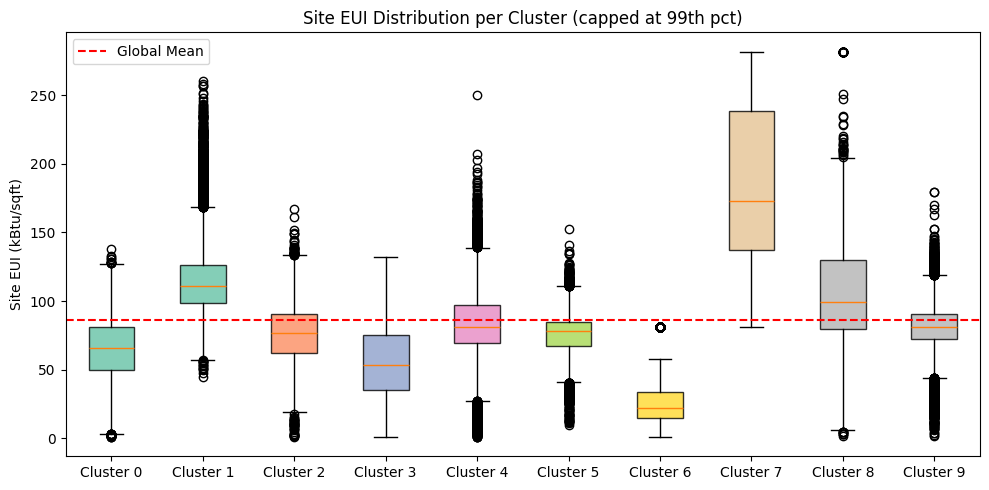

In [19]:
# 9.2 — Site EUI box plots per cluster
fig, ax = plt.subplots(figsize=(10, 5))

data_per_cluster = [
    clean_df_labeled[clean_df_labeled['cluster'] == k]['site_eui'].dropna().clip(
        upper=clean_df['site_eui'].quantile(0.99)
    ).values
    for k in range(N_CLUSTERS)
]

bp = ax.boxplot(data_per_cluster, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticklabels([f'Cluster {k}' for k in range(N_CLUSTERS)])
ax.set_ylabel('Site EUI (kBtu/sqft)')
ax.set_title('Site EUI Distribution per Cluster (capped at 99th pct)')
ax.axhline(y=clean_df['site_eui'].mean(), color='red', linestyle='--', label='Global Mean')
ax.legend()
plt.tight_layout()
plt.show()

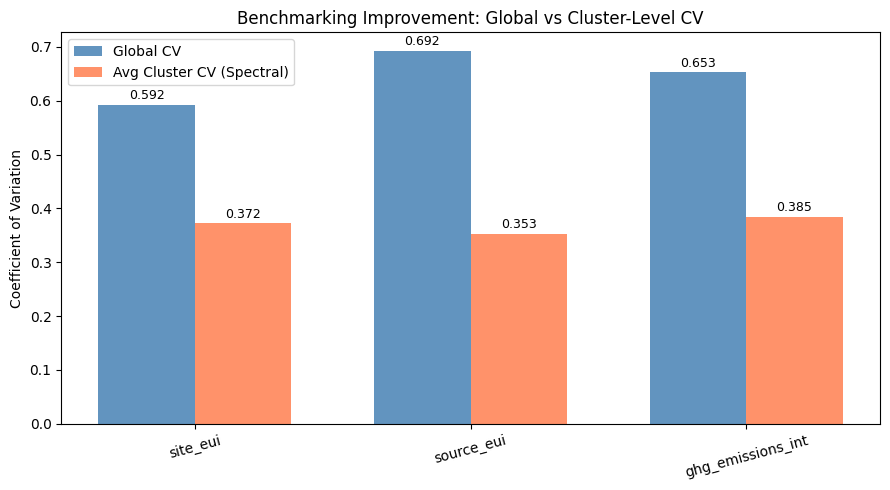

In [20]:
# 9.3 — CV Comparison: Global vs Cluster-level
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(TARGET_COLS))
width = 0.35

global_cvs = [global_stats[c]['cv'] for c in TARGET_COLS]
cluster_cvs = [cluster_stats[f'{c}_cv'].mean() for c in TARGET_COLS]

bars1 = ax.bar(x - width/2, global_cvs, width, label='Global CV', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, cluster_cvs, width, label='Avg Cluster CV (Spectral)', color='coral', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(TARGET_COLS, rotation=15)
ax.set_ylabel('Coefficient of Variation')
ax.set_title('Benchmarking Improvement: Global vs Cluster-Level CV')
ax.legend()

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

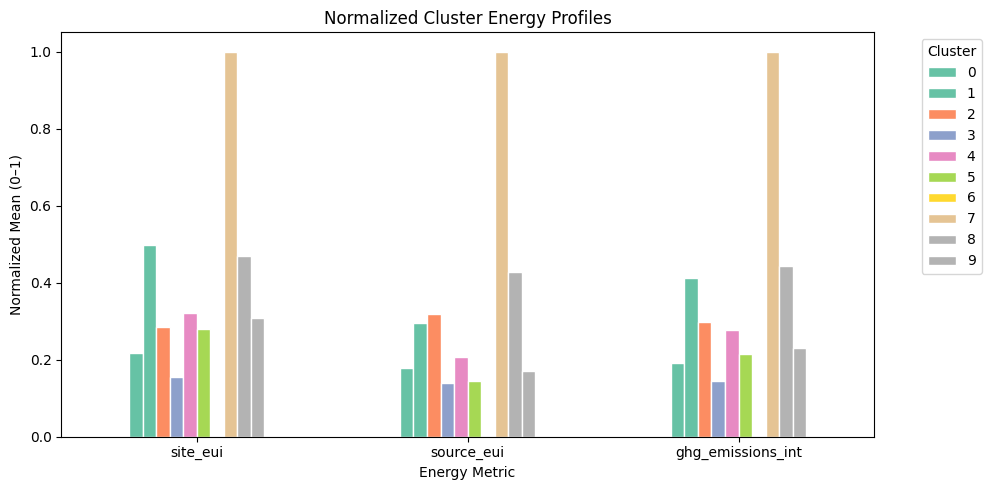

In [21]:
# 9.4 — Cluster profiles: mean site_eui, source_eui, ghg per cluster
profile = clean_df_labeled.groupby('cluster')[TARGET_COLS].mean()

profile_norm = (profile - profile.min()) / (profile.max() - profile.min())  # normalize 0-1 for radar-like bar

profile_norm.T.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.title('Normalized Cluster Energy Profiles')
plt.ylabel('Normalized Mean (0–1)')
plt.xlabel('Energy Metric')
plt.xticks(rotation=0)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

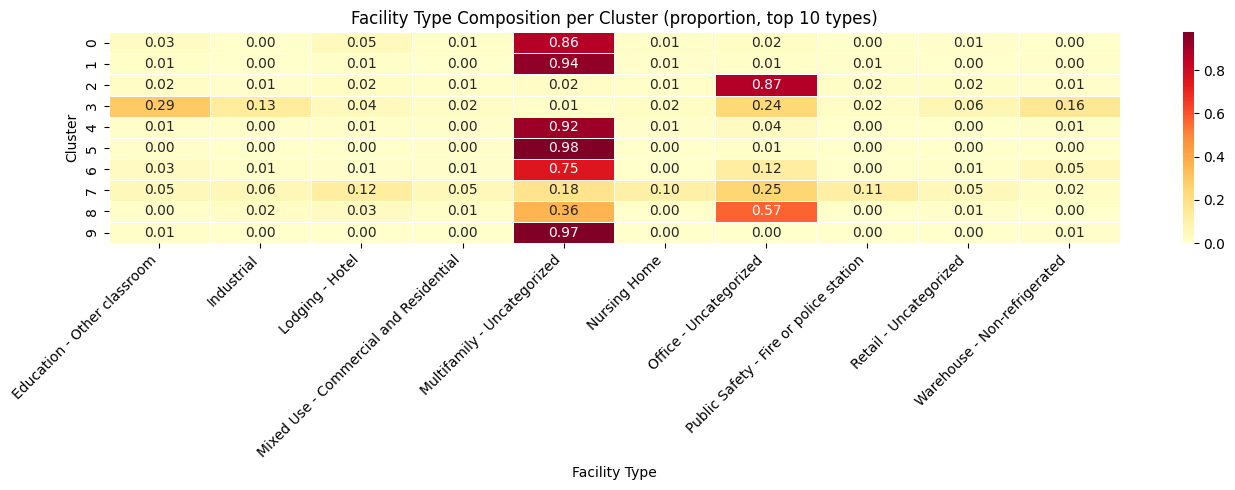

In [22]:
# 9.5 — Facility type distribution across clusters (heatmap)
top_types = clean_df['facility_type'].value_counts().head(10).index
subset = clean_df_labeled[clean_df_labeled['facility_type'].isin(top_types)]

ct = pd.crosstab(subset['cluster'], subset['facility_type'], normalize='index')

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(ct, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Facility Type Composition per Cluster (proportion, top 10 types)')
ax.set_xlabel('Facility Type')
ax.set_ylabel('Cluster')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 10. Save Results

In [23]:
# Save labeled dataset
output_path = BASE_PATH + 'spectral_clustered_data.csv'
clean_df_labeled.to_csv(output_path, index=False)
print(f"Saved labeled data to: {output_path}")

# Save metrics summary
metrics_output = BASE_PATH + 'spectral_metrics_summary.csv'
metrics_summary.to_csv(metrics_output, index=False)
print(f"Saved metrics summary to: {metrics_output}")

# Save benchmarking tables
bq_df.to_csv(BASE_PATH + 'spectral_benchmarking_quality.csv', index=False)
bi_df.to_csv(BASE_PATH + 'spectral_benchmarking_improvement.csv', index=False)
print("All results saved!")

Saved labeled data to: /content/sample_data/data/spectral_clustered_data.csv
Saved metrics summary to: /content/sample_data/data/spectral_metrics_summary.csv
All results saved!


## 11. Summary

| Component | Details |
|---|---|
| Algorithm | Spectral Clustering (nearest_neighbors affinity) |
| k selection | Eigengap heuristic on normalized graph Laplacian |
| Feature input | 9 PCA components from processed data |
| Sample size | 5,000 (centroids used to assign all 135,735 buildings) |
| Evaluation | Silhouette, Davies-Bouldin, Calinski-Harabasz |
| Benchmarking | CV reduction vs global baseline on site_eui, source_eui, ghg |

**Interpretation guide:**
- A **higher Silhouette** (closer to 1) means clusters are well-separated and compact.
- A **lower Davies-Bouldin** means clusters are more distinct.
- A **lower cluster CV** vs global CV confirms that clustering creates more homogeneous peer groups for fair energy benchmarking.